In [18]:
import argparse
from model.TSPN import Transparent_Signal_Processing_Network
from trainer.trainer_basic import Basic_plmodel

import torch
from pytorch_lightning import seed_everything
from configs.config import parse_arguments,config_network
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
parser = argparse.ArgumentParser(description='TSPN')
parser.add_argument('--config_dir', type=str, default='configs/a_031_HUST/config_basic.yaml',help='The directory of the configuration file')
# 适用于jupyter
meta_args = parser.parse_known_args()[0]
config_dir = meta_args.config_dir
configs,args,path,name = parse_arguments(config_dir, 0)
signal_processing_modules, feature_extractor_modules = config_network(configs,args)
MODEL_DICT = {'TSPN': lambda args: Transparent_Signal_Processing_Network(signal_processing_modules, feature_extractor_modules,args)}
model_plain = MODEL_DICT[args.model](args)
model = Basic_plmodel(model_plain, args)
state_dict = torch.load("./save/test/model_tson_hust_20hz.ckpt")
model.load_state_dict(state_dict['state_dict'])
print(model)

Running experiment: model_TSPNtime21-13-52-06_datasetHUST_031_Basic_it0
# build signal processing layers
# build feature extractor layers
# build classifier
Basic_plmodel(
  (network): Transparent_Signal_Processing_Network(
    (signal_processing_layers): ModuleList(
      (0): SignalProcessingLayer(
        (norm): InstanceNorm1d(3, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (weight_connection): Linear(in_features=3, out_features=12, bias=True)
        (signal_processing_modules): SignalProcessingModuleDict(
          (HT): HilbertTransform()
          (LNO): Laplace_neural_operator()
          (I): Identity()
        )
        (skip_connection): Linear(in_features=3, out_features=12, bias=True)
      )
      (1-3): 3 x SignalProcessingLayer(
        (norm): InstanceNorm1d(12, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
        (weight_connection): Linear(in_features=12, out_features=12, bias=True)
        (signal_processing_modules

C:\Users\CCSLab\AppData\Local\Temp\ipykernel_10284\286055088.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("./save/test/model_tson_hust_20hz.c

In [19]:
fault_type_list = ['Norm','Inner Fault','Inner Fault','Outer Fault','Outer Fault','Ball Fault','Ball Fault','Combination Fault','Combination Fault']
def get_LON_signal(model, signal):
    for idx, layer in enumerate(model.signal_processing_layers):
        signal = layer(signal)
    return signal

def compute_frequency_domain(signal):
    fft_values = torch.fft.rfft(signal)
    fft_values = fft_values.detach().cpu().numpy()
    # 去除直流项
    fft_values[0] = 0
    return np.abs(fft_values)

def plot_signal(signal, savename):
    plt.rcParams['font.family'] = 'Times New Roman'
    
    fig, axs = plt.subplots(4, 2, figsize=(16, 4))
   
    for i in range(4):
        signal_time = F.normalize(signal[i,:],dim=0)
        t = np.linspace(0, 1, signal_time.shape[0])
        signal_time = signal_time.detach().cpu().numpy()
        signal_fft = compute_frequency_domain(signal[i,:])
        axs[i,0].plot(t, signal_time,linewidth=1.0 ,c='peru')
        axs[i,1].plot(signal_fft,linewidth=1.0 ,c='darkolivegreen')
        if i == 3:
            axs[i,0].set_xlabel('Time (s)')
            axs[i,1].set_xlabel('Frequency (Hz)')
        else:
            axs[i,0].set_xticks([])
            axs[i,1].set_xticks([])
    fig.subplots_adjust(wspace=0.1, hspace=0.1)
    # fig.tight_layout()
    plt.savefig(savename)

def plot_ori_signal(number, signal):
    plt.rcParams['font.family'] = 'Times New Roman'
    test_signal = signal[number,:,:].unsqueeze(0)
    signal_time = F.normalize(test_signal[0,:,0],dim=0)
    fig, axs = plt.subplots(1, 2, figsize=(8, 2))
    signal_time = signal_time.detach().cpu().numpy()
    signal_fft = compute_frequency_domain(test_signal[0,:,0])
    t = np.linspace(0, 1, 4096)
    axs[0].plot(t, signal_time,linewidth=0.5 ,c='peru')
    axs[0].set_xlabel('Time (s)')
    axs[0].set_ylabel('Amplitude')
    axs[0].set_title(fault_type_list[number//63])
    axs[1].plot(signal_fft,linewidth=0.5 ,c='darkolivegreen')
    axs[1].set_xlabel('Frequency (Hz)')
    axs[1].set_ylabel('Amplitude')
    axs[1].set_title(fault_type_list[number//63])
    fig.tight_layout()
    plt.savefig('save/figure/tson/'+fault_type_list[number//63]+'_original.svg')

torch.Size([12, 4096])
torch.Size([12, 4096])
torch.Size([12, 4096])
torch.Size([12, 4096])
torch.Size([12, 4096])


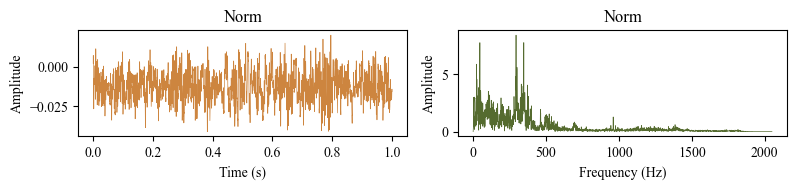

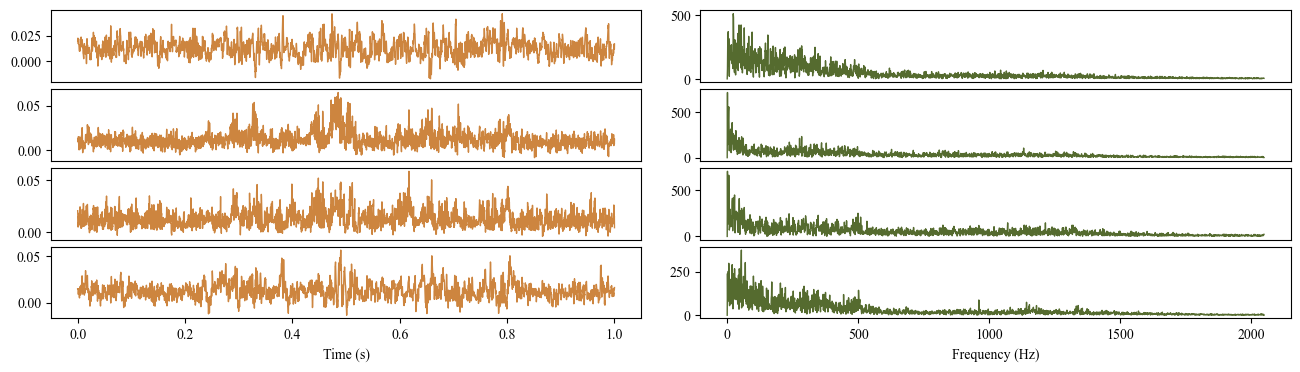

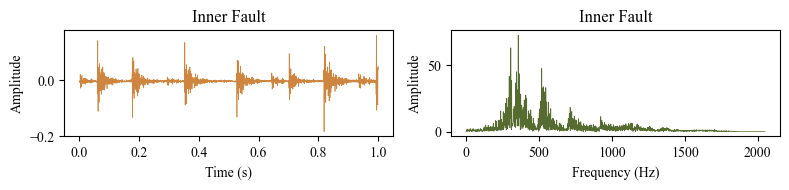

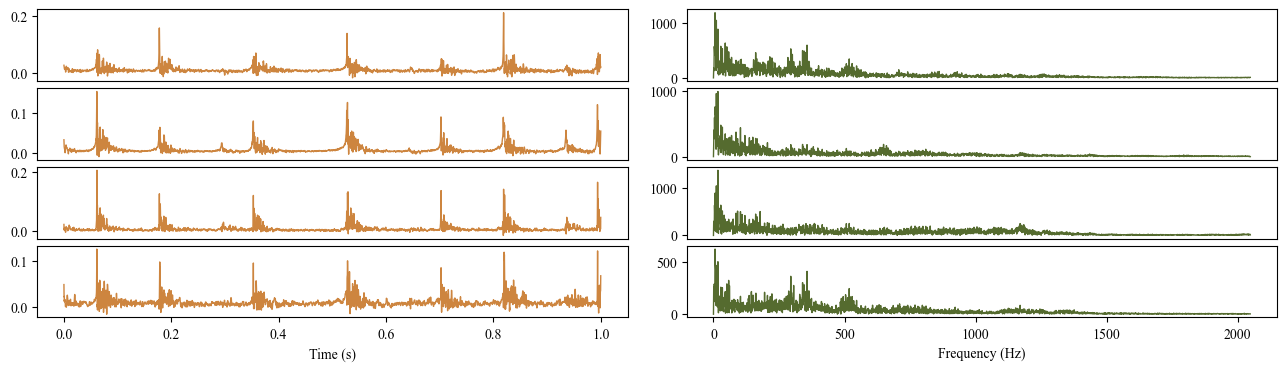

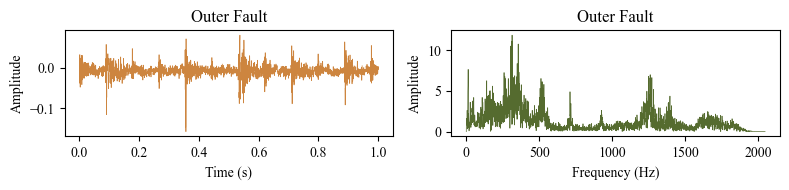

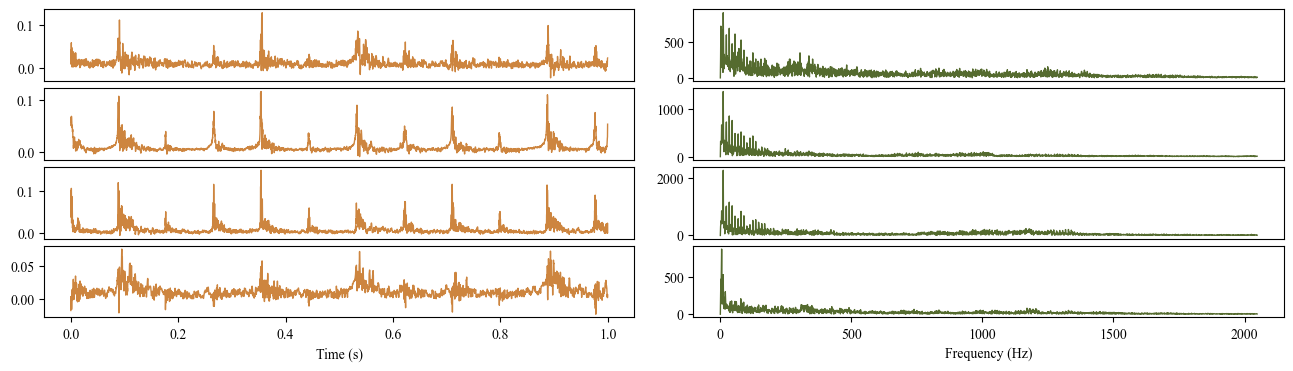

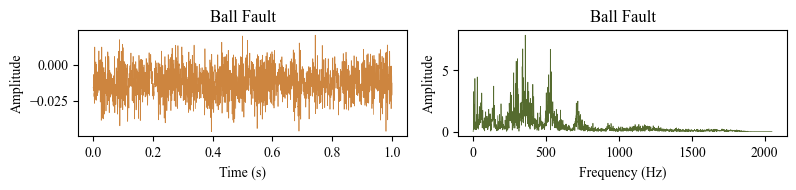

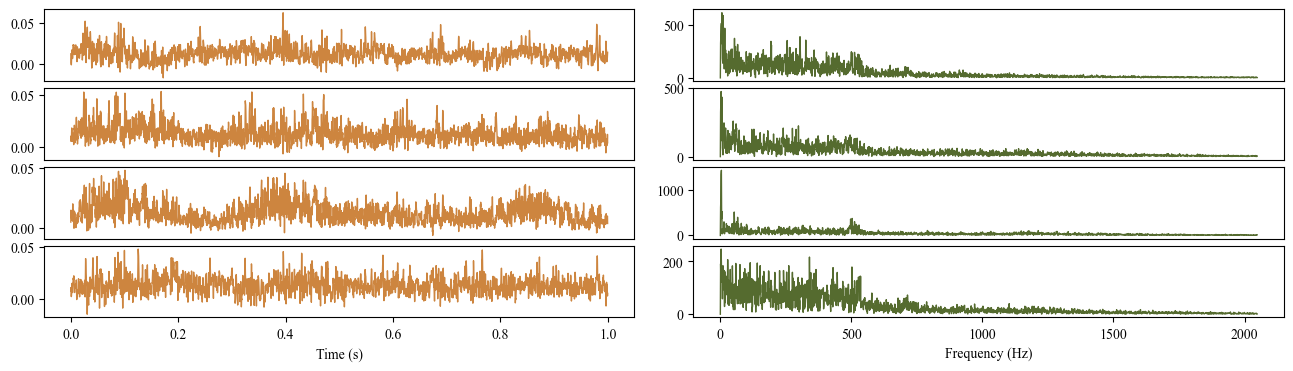

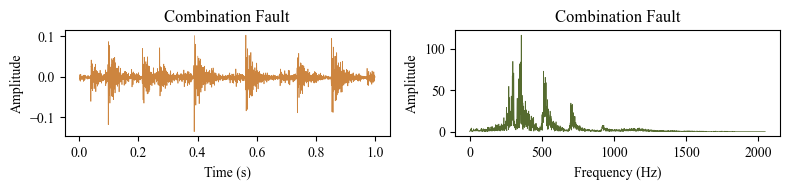

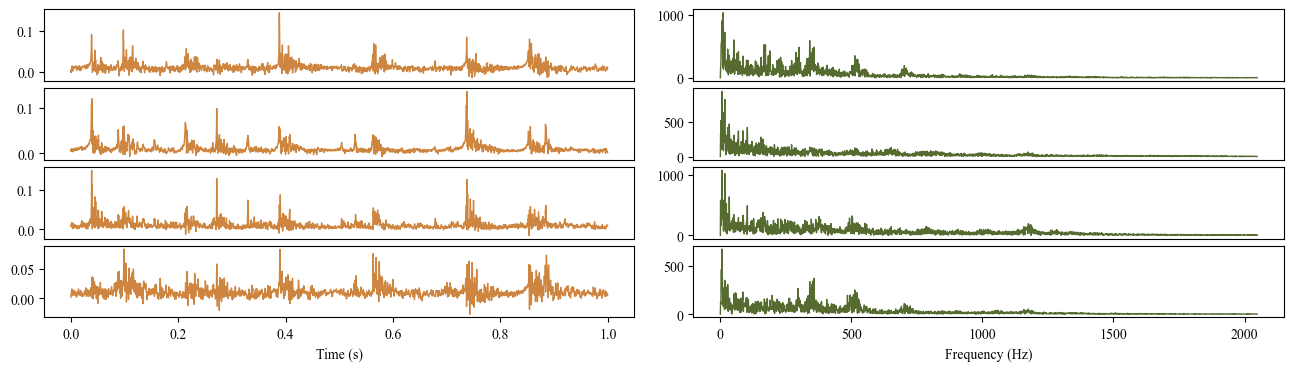

In [20]:
test_data = np.load("C:/Users/CCSLab/Desktop/HUST_bearing/HUST_bearing_20Hz_data.npy")
test_signal = torch.from_numpy(test_data).cuda().float()
signal_num_list = [10, 100, 200, 350, 480]
for signal_num in signal_num_list:
    plot_ori_signal(signal_num, test_signal)
    output_signal = get_LON_signal(model.network.cuda(), test_signal)[signal_num,:,:]
    output_signal = output_signal.T
    print(output_signal.shape)
    plot_signal(output_signal, 'save/figure/lon/signal' + str(signal_num) + '.svg')

In [21]:
# # normal:10, inner:100, outer:200, ball: 350, combo: 480
# def compute_frequency_domain(signal):
#     fft_values = torch.fft.rfft(signal)
#     fft_values = fft_values.detach().cpu().numpy()
#     return np.abs(fft_values)

# def plot_signal(number, signal):
#     plt.rcParams['font.family'] = 'Times New Roman'
#     test_signal = signal[number,:,:].unsqueeze(0)
#     signal_time = F.normalize(test_signal[0,:,0],dim=0)
#     fig, axs = plt.subplots(1, 2, figsize=(8, 2))
#     signal_time = signal_time.detach().cpu().numpy()
#     signal_fft = compute_frequency_domain(test_signal[0,:,0])
#     t = np.linspace(0, 1, 4096)
#     axs[0].plot(t, signal_time,linewidth=0.5 ,c='peru')
#     axs[0].set_xlabel('Time (s)')
#     axs[0].set_ylabel('Amplitude')
#     axs[0].set_title(fault_type_list[number//63])
#     axs[1].plot(signal_fft,linewidth=0.5 ,c='darkolivegreen')
#     axs[1].set_xlabel('Frequency (Hz)')
#     axs[1].set_ylabel('Amplitude')
#     axs[1].set_title(fault_type_list[number//63])
#     fig.tight_layout()
#     plt.savefig('save/figure/tson/'+fault_type_list[number//63]+'_original.svg')

# def hook_fn(module, input, output, num=10):
#     fig, axs = plt.subplots(1, 2, figsize=(8, 2))
#     output_signal = F.normalize(output[num, :, 0], dim=0)
#     signal_time = output_signal.detach().cpu().numpy()
#     signal_fft = compute_frequency_domain(output_signal)
#     t = np.linspace(0, 1, 4096)
#     axs[0].plot(t, signal_time,linewidth=0.5 ,c='peru')
#     axs[0].set_xlabel('Time (s)')
#     axs[0].set_ylabel('Amplitude')
#     axs[0].set_title(fault_type_list[num//63])
#     axs[1].plot(signal_fft,linewidth=0.5 ,c='darkolivegreen')
#     axs[1].set_xlabel('Frequency (Hz)')
#     axs[1].set_ylabel('Amplitude')
#     axs[1].set_title(fault_type_list[num//63])
#     fig.tight_layout()
#     plt.savefig('save/figure/tson/'+fault_type_list[num//63]+'_tson.svg')

# # signal_num_list = [10]
# for signal_num in signal_num_list:
#     plot_signal(signal_num, test_signal)
#     model.network.signal_processing_layers[3].skip_connection.register_forward_hook(lambda module, input, output: hook_fn(module, input, output, num=signal_num))
#     output = model(test_signal)


In [22]:
# # 计算不同类型的故障在SOL前后特征值的不同, 保存为csv文件
# for feature_operator in model.network.feature_extractor_modules:
#     print(model.network.feature_extractor_modules[feature_operator](test_signal).shape)
# model.network.feature_extractor_modules
signal_num_list = [10, 100, 200, 350, 480]
# signal_num_list = [10]
ori_feature_mean_list = []
output_feature_mean_list = []
ori_feature_std_list = []
output_feature_std_list = []

for signal_num in signal_num_list:
    ori_feature_list_5 = []
    output_feature_list_5 = []
    for i in range(5):
        ori_signal = test_signal[signal_num+i,:,:]
        ori_signal = ori_signal.T
        output_signal = get_LON_signal(model.network.cuda(), test_signal)[signal_num+i,:,:]
        output_signal = output_signal.T

        ori_feature_list = []
        output_feature_list = []
        # print(ori_signal.shape, output_signal.shape)
        for feature_operator in model.network.feature_extractor_modules:
            ori_feature= model.network.feature_extractor_modules[feature_operator](ori_signal)
            ori_feature_list.append(ori_feature)
            output_feature = model.network.feature_extractor_modules[feature_operator](output_signal)
            output_feature_list.append(output_feature)
        # 取第一个通道的特征值
        ori_feature_list = torch.cat(ori_feature_list, dim=1).detach().cpu().numpy()
        ori_feature_list_5.append(ori_feature_list[0,:])
        output_feature_list = torch.cat(output_feature_list, dim=1).detach().cpu().numpy()
        output_feature_list_5.append(output_feature_list[0,:])
    ori_feature_list_5 = np.array(ori_feature_list_5)
    output_feature_list_5 = np.array(output_feature_list_5)
    print(ori_feature_list_5.shape, output_feature_list_5.shape)

    # 计算均值和标准差
    ori_feature_mean = np.mean(ori_feature_list_5, axis=0)
    output_feature_mean = np.mean(output_feature_list_5, axis=0)
    ori_feature_std = np.std(ori_feature_list_5, axis=0)
    output_feature_std = np.std(output_feature_list_5, axis=0)
    ori_feature_mean_list.append(ori_feature_mean)
    output_feature_mean_list.append(output_feature_mean)
    ori_feature_std_list.append(ori_feature_std)
    output_feature_std_list.append(output_feature_std)
    # 将均值和方差保存到xls
    # df = pd.DataFrame({'ori_mean': ori_feature_mean, 'output_mean': output_feature_mean,
    #                   'ori_std': ori_feature_std, 'output_std': output_feature_std})
    # df.to_excel('save/figure/weight/'+str(signal_num)+'_feature.xlsx', index=False)

# 将均值和方差转为numpy数组
ori_feature_mean_list = np.array(ori_feature_mean_list)
output_feature_mean_list = np.array(output_feature_mean_list)
ori_feature_std_list = np.array(ori_feature_std_list)
output_feature_std_list = np.array(output_feature_std_list)
print(ori_feature_mean_list.shape, output_feature_mean_list.shape)
    

(5, 13) (5, 13)
(5, 13) (5, 13)
(5, 13) (5, 13)
(5, 13) (5, 13)
(5, 13) (5, 13)
(5, 13) (5, 13)


In [48]:
# 最大最小值归一化
ilist = [1,4,7,2,9,11]
feature_list = ['Std', 'Max', 'Kurtosis', 'Var', 'CrestFactor', 'ClearanceFactor']

fault_list = ['Norm','Inner','Outer','Ball','Comb']
for i in ilist:
    ori_feature_mean_list[:,i] = (ori_feature_mean_list[:,i] - np.min(ori_feature_mean_list[:,i])) / (np.max(ori_feature_mean_list[:,i]) - np.min(ori_feature_mean_list[:,i]))
    output_feature_mean_list[:,i] = (output_feature_mean_list[:,i] - np.min(output_feature_mean_list[:,i])) / (np.max(output_feature_mean_list[:,i]) - np.min(output_feature_mean_list[:,i]))

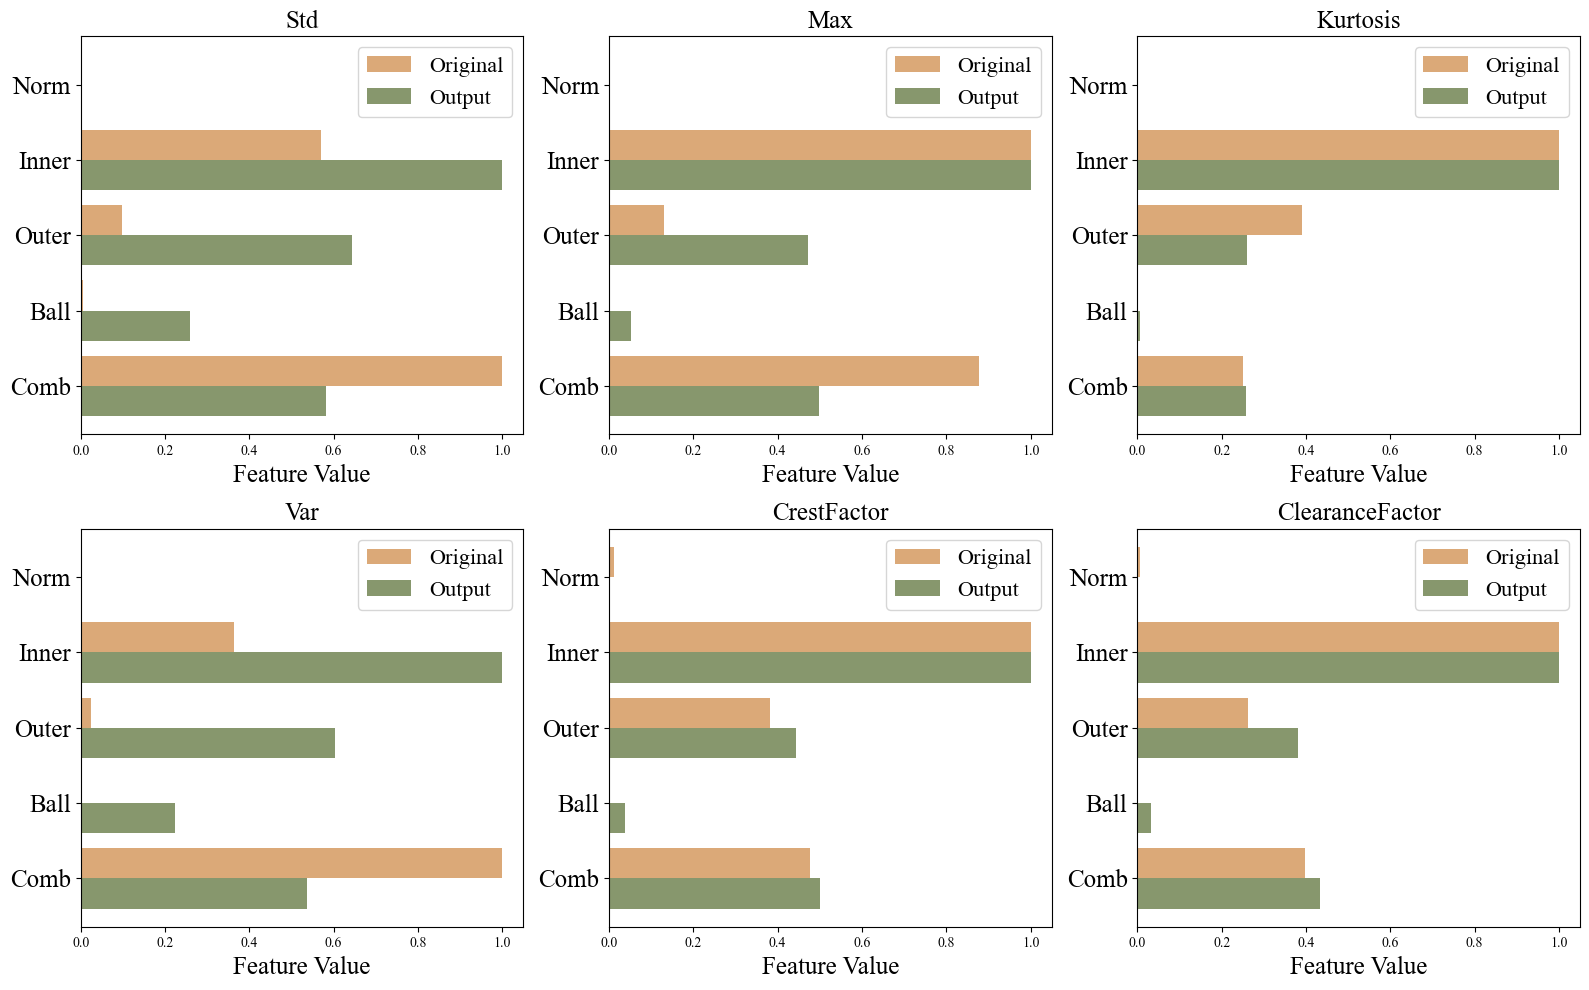

In [51]:
ori_feature_mean_list[:,0].shape, output_feature_mean_list[:,0].shape
# 根据均值和方差绘制横向条形图
# 定义条形图的宽度
bar_width = 0.4
indices = np.array([4,3,2,1,0])  # 横坐标索引

plt.rcParams['font.family'] = 'Times New Roman'
# 绘制2*3子图
fig, axs = plt.subplots(2, 3, figsize=(16, 10))
for ii in range(6):
    i = ilist[ii]
    # 绘制横向条形图
    axs[ii//3,ii%3].barh(indices + bar_width / 2, ori_feature_mean_list[:,i], bar_width, label='Original', color='peru', alpha=0.7, capsize=5)
    axs[ii//3,ii%3].barh(indices - bar_width / 2, output_feature_mean_list[:,i], bar_width,  label='Output', color='darkolivegreen', alpha=0.7, capsize=5)
    # 添加图例和标签
    # plt.xlabel('Feature Value')
    axs[ii//3,ii%3].set_yticks(indices, labels=fault_list, fontsize=18)
    axs[ii//3,ii%3].set_title(feature_list[ii], fontsize=18)
    axs[ii//3,ii%3].set_xlabel('Feature Value', fontsize=18)
    axs[ii//3,ii%3].legend(loc='upper right', fontsize=16)
    # plt.title('Feature Comparison with Error Bars')
    # plt.yticks(indices, [f'Feature {i+1}' for i in indices])  # 设置y轴标签
# plt.legend()

plt.tight_layout()
# plt.show()
plt.savefig('save/figure/weight/feature_mean.svg')
